# Corrective RAG (CRAG)

**Corrective Retrieval-Augmented Generation (CRAG)** is an advanced RAG strategy that introduces
a self-correction mechanism to improve the quality of retrieved documents before generation.

## Workflow Architecture

<div align="center">
  <img src="workflow_architecture.png" alt="Corrective RAG Workflow Diagram" width="400" />
</div>

<details>
<summary><b>Click to expand Mermaid Source Code</b></summary>

```mermaid
flowchart TD
    Start([User Question]) --> retrieve["1. retrieve<br/>Fetch docs from FAISS<br/><i>(HuggingFace Embeddings)</i>"]
    retrieve --> grade_documents["2. grade_documents<br/>Evaluate doc relevance<br/><i>(Groq LLM Grader)</i>"]
    
    grade_documents --> decide{"All Documents<br/>Relevant?"}
    
    decide -->|Yes: web_search = No| generate["5. generate<br/>Synthesize final answer<br/><i>(Groq LLM RAG Chain)</i>"]
    decide -->|No: web_search = Yes| transform_query["3. transform_query<br/>Re-write query for search<br/><i>(Groq LLM Rewriter)</i>"]
    
    transform_query --> web_search_node["4. web_search_node<br/>Fetch supplementary web results<br/><i>(Tavily Search)</i>"]
    web_search_node --> generate
    
    generate --> End([Final Grounded Answer])
```

</details>

## How It Works

1. **Retrieve** — Fetch documents from a vector store based on the user query.
2. **Grade Documents** — An LLM evaluates each retrieved document for relevance.
3. **Decide**:
   - If **all** documents are relevant → **Generate** the answer directly.
   - If **any** document is irrelevant → **Transform the query** and do a **web search**.
4. **Generate** — Produce the final answer using the (corrected) context.

## Key Components
- **Retrieval Grader** — Binary relevance scoring of retrieved documents.
- **Question Re-writer** — Optimizes the query for web search.
- **Web Search Tool** (Tavily) — Fetches supplementary real-time context.
- **LangGraph Workflow** — Orchestrates the nodes and conditional edges.

## Tech Stack
| Layer | Technology |
|-------|------------|
| Embeddings | HuggingFace `sentence-transformers/all-MiniLM-L6-v2` |
| LLM | Groq `openai/gpt-oss-120b` (`init_chat_model`) |
| Vector Store | FAISS |
| Web Search | Tavily |
| Orchestration | LangGraph |


## Step 0: Environment Setup

Load API keys from a `.env` file. Ensure the following variables are set:
- `GROQ_API_KEY` — Groq LLM
- `TAVILY_API_KEY` — Tavily web search

**Install packages (if needed):**
```bash
pip install langchain langchain-community langchain-groq langchain-huggingface \
            faiss-cpu langgraph python-dotenv pydantic tiktoken
```


In [2]:
import os
from dotenv import load_dotenv

# Load all environment variables from the .env file
load_dotenv()

# Set User-Agent to avoid WebBaseLoader warnings/blocks
os.environ['USER_AGENT'] = 'CorrectiveRAG/1.0'

# Expose required API keys to LangChain / Groq / Tavily
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')         # Groq LLM API key
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')     # Tavily web-search API key

print('Environment variables loaded successfully.')


Environment variables loaded successfully.


## Step 1: Build the Vector Index

We load web documents, split them into chunks, and store them in a **FAISS** vector store
using **HuggingFace embeddings**.

- **Embeddings Model**: `sentence-transformers/all-MiniLM-L6-v2`
  — lightweight (~80 MB), fast, and accurate. Runs **locally** (no API key needed).
- **Document Sources**: Three Lilian Weng blog posts on LLM agents, prompt engineering,
  and adversarial attacks on LLMs.
- **Chunking**: `RecursiveCharacterTextSplitter` with `chunk_size=500`, `chunk_overlap=0`.


In [3]:
### Step 1 – Build Index

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# ------------------------------------------------------------------
# HuggingFace Embeddings
# sentence-transformers/all-MiniLM-L6-v2 characteristics:
#   - 384-dimensional dense vectors
#   - Excellent for semantic similarity / retrieval tasks
#   - Runs entirely locally — no network call per embedding
# ------------------------------------------------------------------
embedding = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2'
)

# ------------------------------------------------------------------
# Source URLs to index
#   1. LLM-powered autonomous agents
#   2. Prompt engineering techniques
#   3. Adversarial attacks on LLMs
# ------------------------------------------------------------------
urls = [
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/',
    'https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/',
]

# Load each URL; each call returns a list of Document objects
docs = [WebBaseLoader(url).load() for url in urls]

# Flatten list-of-lists into a single list
docs_list = [item for sublist in docs for item in sublist]

# ------------------------------------------------------------------
# Chunk documents for retrieval
# from_tiktoken_encoder counts tokens accurately using tiktoken
# ------------------------------------------------------------------
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500,   # max tokens per chunk
    chunk_overlap=0   # no overlap between chunks
)
doc_splits = text_splitter.split_documents(docs_list)

# ------------------------------------------------------------------
# Build FAISS vector store
# FAISS (Facebook AI Similarity Search) enables fast ANN search
# ------------------------------------------------------------------
vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=embedding
)

# Wrap the vector store as a LangChain retriever
# Default: returns top-4 most similar chunks
retriever = vectorstore.as_retriever()

print(f'Indexed {len(doc_splits)} document chunks into FAISS vector store.')


c:\RAG\Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\itsar\AppData\Local\Temp\ipykernel_45236\372968498.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10644.65it/s]


Indexed 88 document chunks into FAISS vector store.


## Step 2: Retrieval Grader

The **Retrieval Grader** uses a Groq LLM initialized via `init_chat_model` to assess
whether each retrieved document is relevant to the user question.

- **Output**: Binary score — `yes` (relevant) or `no` (not relevant).
- **Structured Output**: Pydantic `BaseModel` enforces typed LLM output.
- **Groq Model**: `openai/gpt-oss-120b` via `init_chat_model(model="groq:openai/gpt-oss-120b")`.


In [4]:
### Step 2 – Retrieval Grader

from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field


# ------------------------------------------------------------------
# Pydantic schema for structured LLM output
# Enforces that the model returns exactly one field: binary_score
# ------------------------------------------------------------------
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Document relevance to the question: 'yes' or 'no'"
    )


# ------------------------------------------------------------------
# Groq LLM — initialized via init_chat_model
# with_structured_output -> forces response to match GradeDocuments
# ------------------------------------------------------------------
llm = init_chat_model(model="groq:openai/gpt-oss-120b")
print("LLM ready")

structured_llm_grader = llm.with_structured_output(GradeDocuments)

# ------------------------------------------------------------------
# Grader prompt
# The model should assess keyword/semantic overlap between the
# document and the question, then return yes or no.
# ------------------------------------------------------------------
system = (
    'You are a grader assessing relevance of a retrieved document to a user question.\n'
    'If the document contains keyword(s) or semantic meaning related to the question,'
    ' grade it as relevant.\n'
    "Give a binary score 'yes' or 'no' to indicate whether the document is relevant."
)

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system),
        ('human', 'Retrieved document:\n\n {document}\n\nUser question: {question}'),
    ]
)

# Build the grader chain: prompt -> structured Groq LLM
retrieval_grader = grade_prompt | structured_llm_grader

# ------------------------------------------------------------------
# Quick sanity test
# ------------------------------------------------------------------
question = 'agent memory'
docs = retriever.invoke(question)           # fetch top-4 chunks
doc_txt = docs[1].page_content             # pick the second chunk

result = retrieval_grader.invoke({'question': question, 'document': doc_txt})
print(f'Grading result for chunk 1: {result}')


LLM ready
Grading result for chunk 1: binary_score='yes'


## Step 3: RAG Generation Chain

The **generation chain** takes filtered documents + the user question and produces a
grounded answer via the Groq LLM.

- **Prompt**: `rlm/rag-prompt` from LangChain Hub — standard grounded-QA template.
- **Model**: Groq `groq:openai/gpt-oss-120b` via `init_chat_model`.
- **Output Parser**: `StrOutputParser` returns a clean string.


In [5]:
### Step 3 – RAG Generation Chain

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain.chat_models import init_chat_model

# ------------------------------------------------------------------
# Standard RAG prompt (equivalent to rlm/rag-prompt on LangChain Hub)
# Instructs the LLM: answer ONLY from the provided context.
# ------------------------------------------------------------------
prompt = ChatPromptTemplate.from_template(
    """You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:"""
)

# ------------------------------------------------------------------
# Groq LLM — generation role
# ------------------------------------------------------------------
llm = init_chat_model(model="groq:openai/gpt-oss-120b")


def format_docs(docs):
    """Concatenate page_content fields of a list of Documents."""
    return '\n\n'.join(doc.page_content for doc in docs)


# Chain: prompt -> Groq LLM -> plain string
rag_chain = prompt | llm | StrOutputParser()

# Quick test (reuses docs and question from the grader step)
generation = rag_chain.invoke({'context': docs, 'question': question})
print(generation)


In LLM‑powered autonomous agents, **short‑term memory** refers to the model’s in‑context learning—information held temporarily in the prompt during a single interaction. **Long‑term memory** is an external store (often a vector database) that lets the agent retain and retrieve unlimited knowledge across sessions. Together they enable the agent to recall past events and use that context for future planning and reasoning.


## Step 4: Question Re-writer

When retrieved documents are not relevant, the **Question Re-writer** reformulates the
original question into a version better suited for web search.

- Reasons about the **semantic intent** of the original question.
- Produces a more specific, search-engine-friendly rephrasing.
- The improved query feeds into the Tavily web-search node.


In [6]:
### Step 4 – Question Re-writer

from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Groq LLM — rewriter role
llm = init_chat_model(model="groq:openai/gpt-oss-120b")

# System instruction: analyse intent, return search-optimised question
system = (
    'You are a question re-writer that converts an input question to a better version\n'
    'optimised for web search. Look at the input and reason about the underlying\n'
    'semantic intent / meaning.'
)

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system),
        (
            'human',
            'Here is the initial question:\n\n {question} \n Formulate an improved question.',
        ),
    ]
)

# Chain: re-write prompt -> Groq LLM -> plain string
question_rewriter = re_write_prompt | llm | StrOutputParser()

# Test
rewritten = question_rewriter.invoke({'question': question})
print(f'Original : {question}')
print(f'Rewritten: {rewritten}')


Original : agent memory
Rewritten: **Improved question:**  
*How do artificial‑intelligence agents store and use memory, and what common memory architectures or techniques are used to enable them to make informed decisions?*


## Step 5: Web Search Tool

**Tavily Search** performs real-time web searches to supplement the vector store
retrieval when documents are not relevant.

- `k=3`: Returns the top 3 search results.
- Results are appended to the document list as a single `Document` object.


In [7]:
### Step 5 – Web Search Tool

from langchain_community.tools.tavily_search import TavilySearchResults

# k=3: return top-3 web results per query
# Requires TAVILY_API_KEY set in the environment
web_search_tool = TavilySearchResults(k=3)

print('Tavily web search tool initialised.')


Tavily web search tool initialised.


C:\Users\itsar\AppData\Local\Temp\ipykernel_45236\1084569798.py:7: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


## Step 6: Define Graph State

`GraphState` is the shared, typed dictionary passed between every node.

| Key | Type | Description |
|-----|------|-------------|
| `question` | `str` | User question (possibly rewritten) |
| `generation` | `str` | LLM-generated final answer |
| `web_search` | `str` | `'Yes'` if web search needed, `'No'` otherwise |
| `documents` | `List[str]` | Retrieved / filtered / web-search documents |


In [8]:
### Step 6 – Graph State

from typing import List
from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Shared state of the CRAG LangGraph workflow.

    Attributes
    ----------
    question   : User question (may be rewritten for web search).
    generation : Final LLM-generated answer.
    web_search : 'Yes' if web search is triggered; 'No' otherwise.
    documents  : List of retrieved / filtered / web documents.
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]


## Step 7: Define Graph Nodes and Conditional Edge

### Nodes
| Node | Description |
|------|-------------|
| `retrieve` | Fetches documents from the FAISS vector store. |
| `grade_documents` | Filters documents by relevance (Groq grader). |
| `transform_query` | Rewrites the question for better web search. |
| `web_search_node` | Runs Tavily search; appends results to documents. |
| `generate` | Produces the final answer via the RAG chain. |

### Conditional Edge — `decide_to_generate`
- `web_search == 'Yes'` → route to `transform_query`
- `web_search == 'No'`  → route to `generate`


In [9]:
### Step 7 – Node Functions and Conditional Edge

from langchain_core.documents import Document


# ── NODE 1: retrieve ──────────────────────────────────────────────────────────
def retrieve(state):
    """
    Retrieve documents from the FAISS vector store.

    Returns updated state with 'documents' key.
    """
    print('---RETRIEVE---')
    question = state['question']

    # Invoke the FAISS retriever; returns top-4 chunks by default
    documents = retriever.invoke(question)
    return {'documents': documents, 'question': question}


# ── NODE 2: generate ──────────────────────────────────────────────────────────
def generate(state):
    """
    Generate the final answer using the RAG chain (Groq LLM).

    Returns updated state with 'generation' key.
    """
    print('---GENERATE---')
    question = state['question']
    documents = state['documents']

    # prompt -> Groq LLM -> string
    generation = rag_chain.invoke({'context': documents, 'question': question})
    return {'documents': documents, 'question': question, 'generation': generation}


# ── NODE 3: grade_documents ───────────────────────────────────────────────────
def grade_documents(state):
    """
    Score each retrieved document for relevance.
    Keep relevant docs; set web_search='Yes' if any doc is irrelevant.

    Returns updated state with filtered 'documents' and 'web_search' flag.
    """
    print('---CHECK DOCUMENT RELEVANCE TO QUESTION---')
    question = state['question']
    documents = state['documents']

    filtered_docs = []   # only relevant documents go here
    web_search = 'No'    # default: all docs are relevant

    for d in documents:
        # Ask the grader LLM: is this chunk relevant?
        score = retrieval_grader.invoke(
            {'question': question, 'document': d.page_content}
        )
        grade = score.binary_score

        if grade == 'yes':
            print('---GRADE: DOCUMENT RELEVANT---')
            filtered_docs.append(d)
        else:
            # Flag that at least one doc is irrelevant -> trigger web search
            print('---GRADE: DOCUMENT NOT RELEVANT---')
            web_search = 'Yes'

    return {'documents': filtered_docs, 'question': question, 'web_search': web_search}


# ── NODE 4: transform_query ───────────────────────────────────────────────────
def transform_query(state):
    """
    Rewrite the question for better web-search results.

    Returns updated state with improved 'question'.
    """
    print('---TRANSFORM QUERY---')
    question = state['question']
    documents = state['documents']

    # Groq LLM rewrites the question to be more search-engine-friendly
    better_question = question_rewriter.invoke({'question': question})
    return {'documents': documents, 'question': better_question}


# ── NODE 5: web_search ────────────────────────────────────────────────────────
def web_search(state):
    """
    Perform a Tavily web search and append results to documents.

    Returns updated state with web results added to 'documents'.
    """
    print('---WEB SEARCH---')
    question = state['question']
    documents = state['documents']

    # Run Tavily search and get top-3 results
    search_results = web_search_tool.invoke({'query': question})

    # Merge all result snippets into a single Document object
    web_content = '\n'.join([r['content'] for r in search_results])
    documents.append(Document(page_content=web_content))

    return {'documents': documents, 'question': question}


# ── CONDITIONAL EDGE: decide_to_generate ─────────────────────────────────────
def decide_to_generate(state):
    """
    Route the workflow based on document relevance.

    Returns
    -------
    'transform_query' : if any document was graded irrelevant.
    'generate'        : if all documents are relevant.
    """
    print('---ASSESS GRADED DOCUMENTS---')
    web_search = state['web_search']

    if web_search == 'Yes':
        # At least one irrelevant doc found -> rewrite query & search web
        print('---DECISION: DOCUMENTS NOT RELEVANT, TRANSFORM QUERY---')
        return 'transform_query'
    else:
        # All docs relevant -> go straight to generation
        print('---DECISION: GENERATE---')
        return 'generate'


LangGraph workflow compiled successfully.


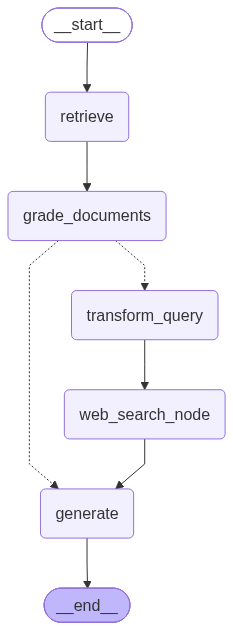

In [10]:
### Step 8 – Build and Compile the LangGraph Workflow

from langgraph.graph import END, StateGraph, START

# Initialise the graph with the shared state schema
workflow = StateGraph(GraphState)

# ── Add nodes ──────────────────────────────────────────────────────────────────
workflow.add_node('retrieve', retrieve)               # Node 1: retrieve from FAISS
workflow.add_node('grade_documents', grade_documents) # Node 2: relevance grader
workflow.add_node('generate', generate)               # Node 3: answer generator
workflow.add_node('transform_query', transform_query) # Node 4: question rewriter
workflow.add_node('web_search_node', web_search)      # Node 5: Tavily web search

# ── Add edges ──────────────────────────────────────────────────────────────────

# Entry: always start with retrieval
workflow.add_edge(START, 'retrieve')

# Fixed: after retrieval, grade all documents
workflow.add_edge('retrieve', 'grade_documents')

# Conditional: after grading, route based on web_search flag
workflow.add_conditional_edges(
    'grade_documents',       # source node
    decide_to_generate,      # routing function
    {
        'transform_query': 'transform_query',  # irrelevant docs found
        'generate': 'generate',                 # all docs relevant
    },
)

# Fixed: after rewriting, run web search
workflow.add_edge('transform_query', 'web_search_node')

# Fixed: after web search, generate the answer
workflow.add_edge('web_search_node', 'generate')

# Fixed: after generation, terminate
workflow.add_edge('generate', END)

# Compile into a runnable application
app = workflow.compile()

print('LangGraph workflow compiled successfully.')
app


## Step 10: Run the CRAG Pipeline

Invoke the compiled app with a user question. The workflow will automatically:
1. Retrieve candidate documents.
2. Grade each for relevance.
3. If needed — rewrite the question and search the web.
4. Generate and return the final grounded answer.


In [12]:
### Step 10 – Run the CRAG Pipeline

# Invoke the CRAG workflow with a sample question
result = app.invoke({'question': 'What are the types of agent memory?'})

# Print the generated answer and metadata
print('=' * 60)
print('FINAL ANSWER')
print('=' * 60)
print(result['generation'])
print('=' * 60)
print(f"Web search triggered : {result['web_search']}")
print(f"Documents used       : {len(result['documents'])}")


---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: DOCUMENTS NOT RELEVANT, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
---GENERATE---
FINAL ANSWER
- **Short‑term (context) memory** stores the raw recent dialogue, tool outputs and current task state needed for the ongoing interaction and is cleared when the session ends.  
- **Working memory** is the actively‑used portion of that context that the agent reasons over to generate plans or actions.  
- **Long‑term memory** persists across sessions and is subdivided into: **episodic memory** (timestamped records of past events or conversations), **semantic memory** (general facts, concepts and accumulated knowledge), and **procedural memory** (reusable skills, rules or strategies).
Web search triggered : Yes
Documents used       : 3


## Summary

| Component | Technology |
|-----------|------------|
| Embeddings | HuggingFace `sentence-transformers/all-MiniLM-L6-v2` |
| Vector Store | FAISS (local, in-memory) |
| LLM — Grader | Groq `openai/gpt-oss-120b (init_chat_model)` |
| LLM — Generator | Groq `openai/gpt-oss-120b (init_chat_model)` |
| LLM — Query Rewriter | Groq `openai/gpt-oss-120b (init_chat_model)` |
| Web Search | Tavily Search API |
| Orchestration | LangGraph `StateGraph` |

### Why CRAG beats plain RAG
- **Self-correcting** — detects poor retrieval and compensates automatically.
- **Adaptive** — falls back to live web search when the knowledge base falls short.
- **Grounded** — uses only verified, relevant context for generation.
- **Modular** — each component (grader, rewriter, searcher) can be swapped independently.
